In [3]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("Pharma_Industry.csv")
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [7]:
# Dataset shape
df.shape

(500, 6)

In [9]:
# Column names & data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [11]:
# Summary statistics (numerical)
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [13]:
# Check missing values
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

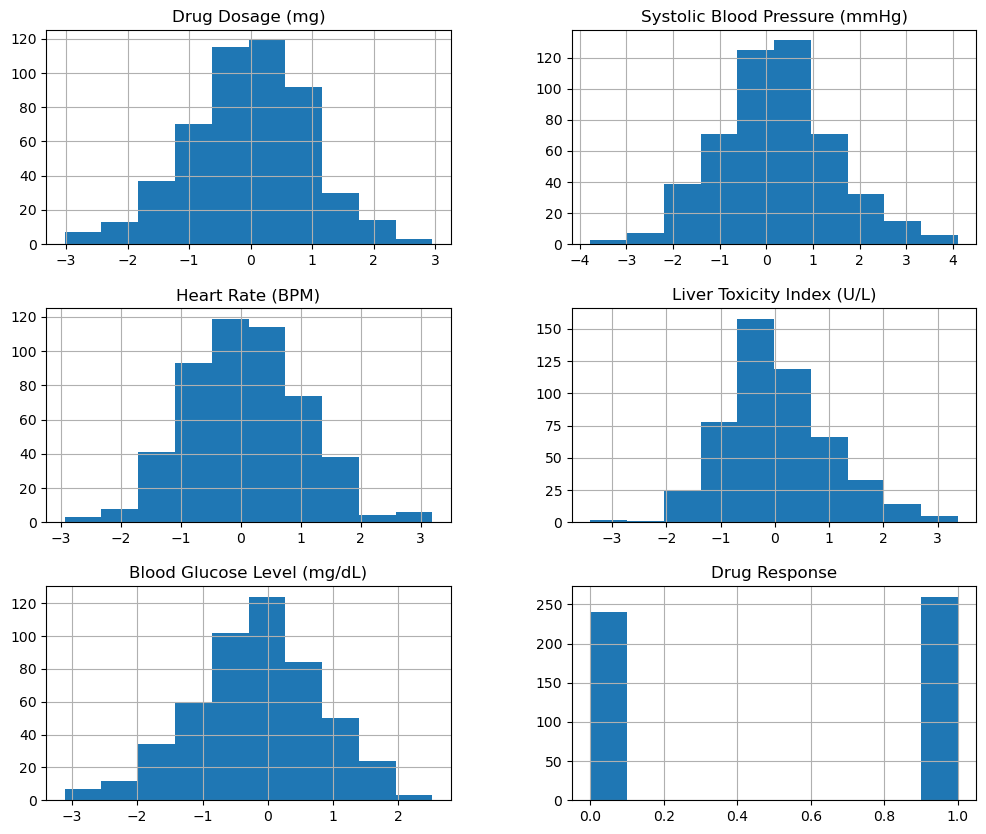

In [15]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 10))
plt.show()

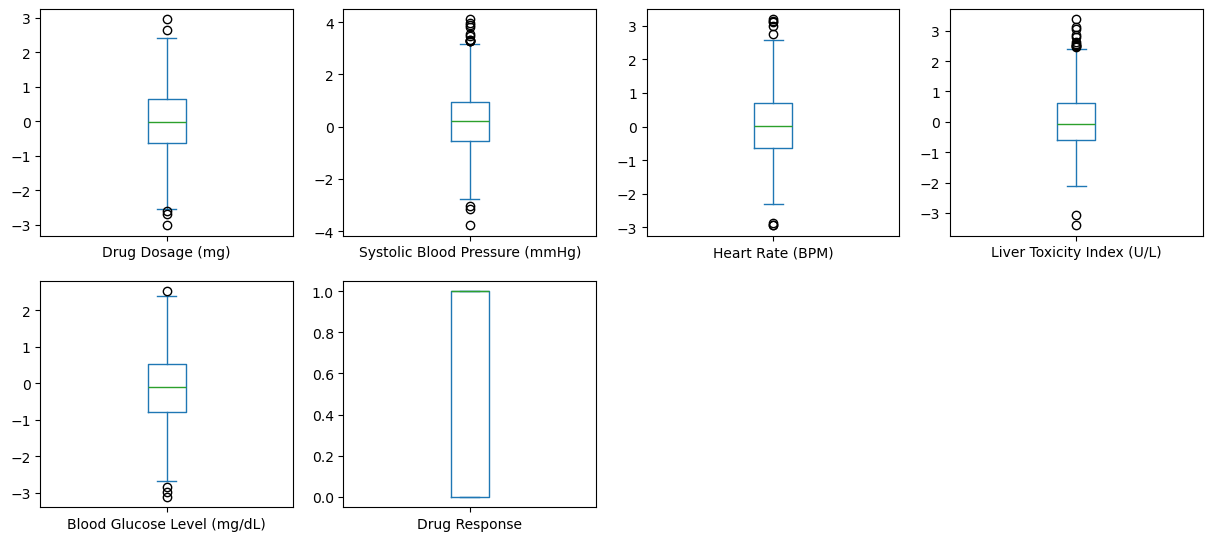

In [16]:
#Box plots
df.plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10))
plt.show()

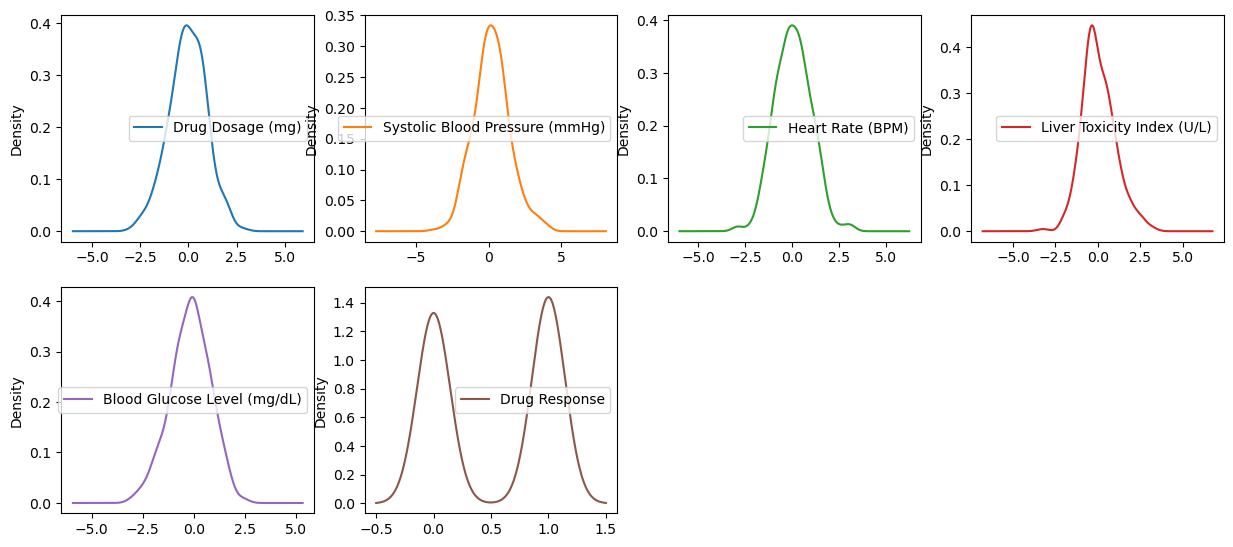

In [17]:
#Density plots
df.plot(kind='density', subplots=True, layout=(3,4), figsize=(15,10), sharex=False)
plt.show()

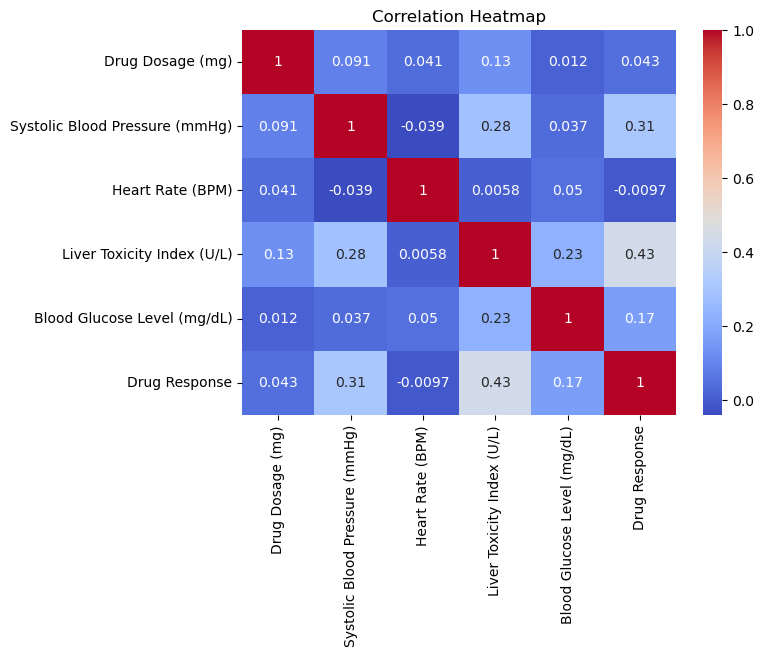

In [18]:
import seaborn as sns

plt.figure(figsize=(7,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index([], dtype='object')

In [20]:
#Label Encoding (for binary categories)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop("Drug Response", axis=1)   
y = df["Drug Response"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((400, 5), (100, 5))

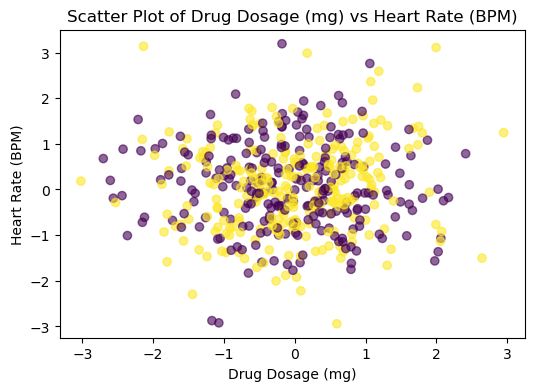

In [25]:
#Scatter Plot
plt.figure(figsize=(6,4))
plt.scatter(df['Drug Dosage (mg)'], df['Heart Rate (BPM)'], c=df['Drug Response'], alpha=0.6)
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Heart Rate (BPM)")
plt.title("Scatter Plot of Drug Dosage (mg) vs Heart Rate (BPM)")
plt.show()

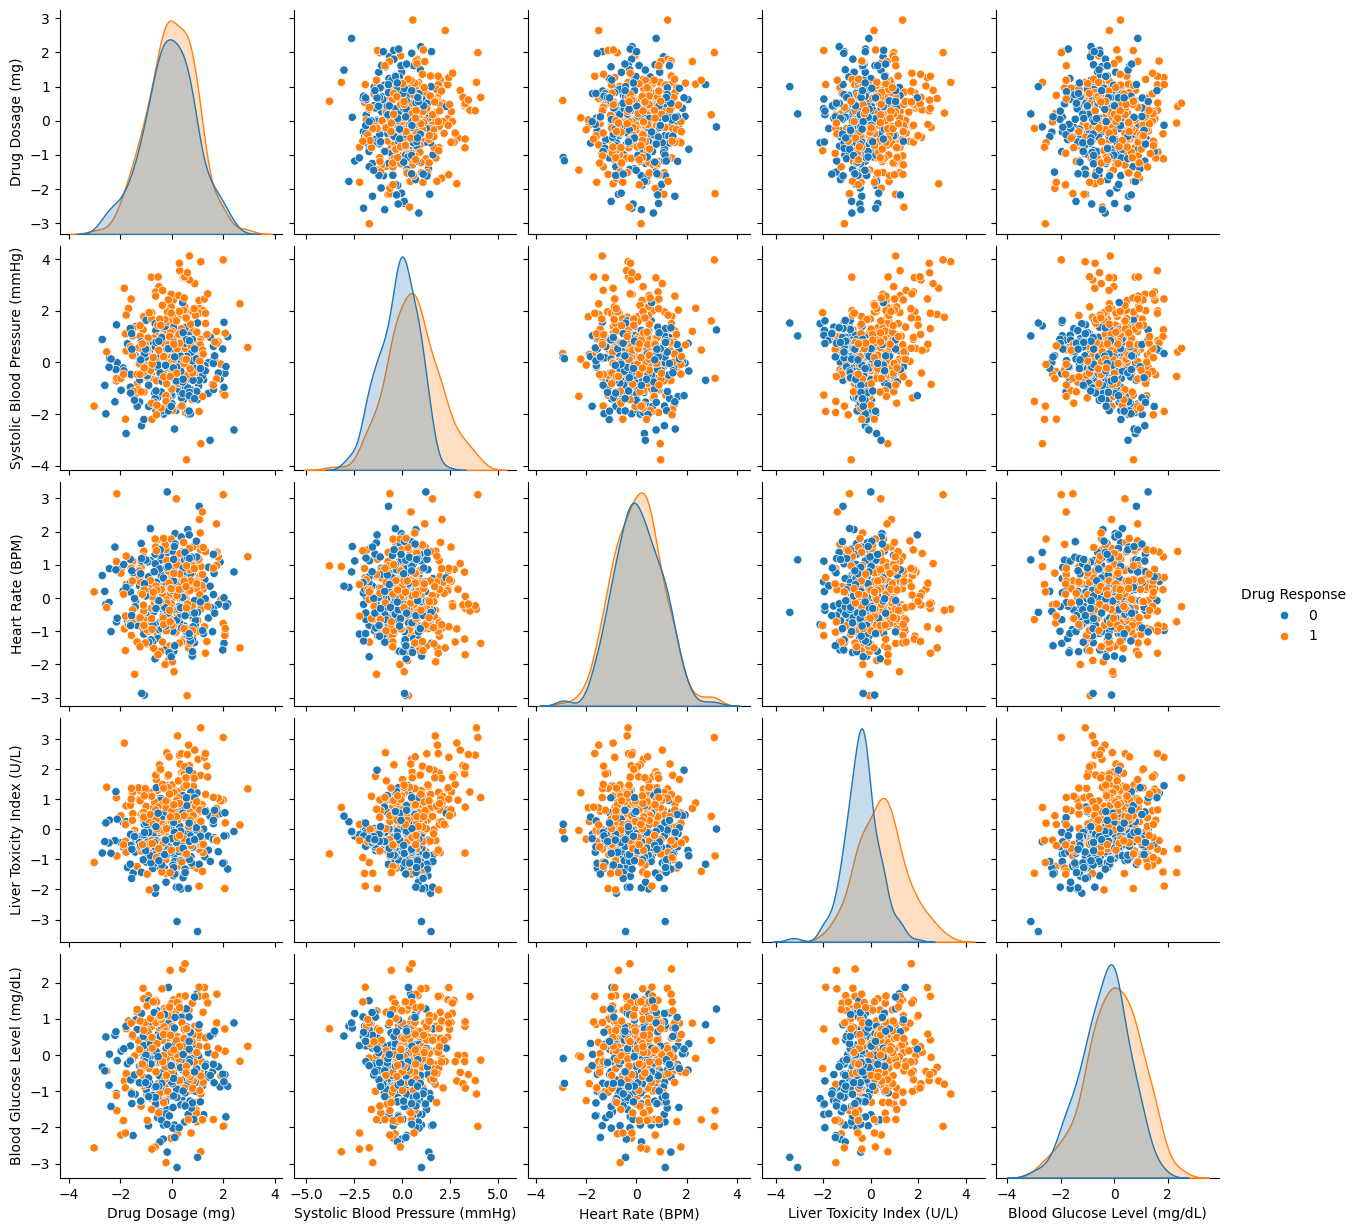

In [26]:
#Pair Plot
sns.pairplot(df, hue="Drug Response")
plt.show()

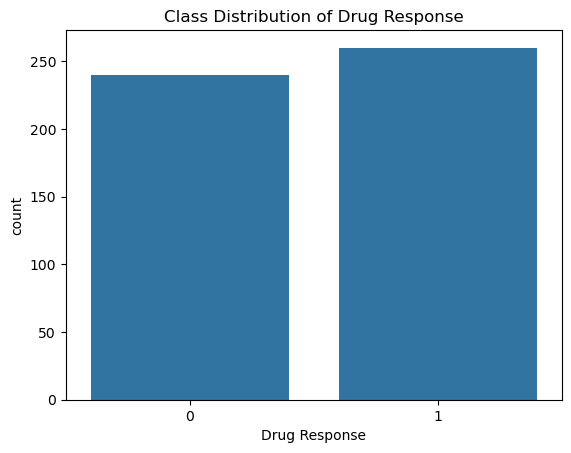

In [27]:
sns.countplot(x='Drug Response', data=df)
plt.title("Class Distribution of Drug Response")
plt.show()

In [35]:
#Percentage distribution
df['Drug Response'].value_counts(normalize=True) * 100

Drug Response
1    52.0
0    48.0
Name: proportion, dtype: float64

In [36]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [37]:
svm_model = SVC(kernel='linear', random_state=42)

svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [38]:
y_pred = svm_model.predict(X_test)

In [45]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.72

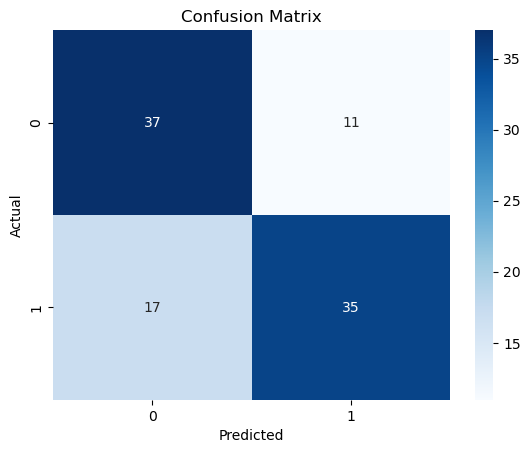

In [47]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [49]:
#Precision, Recall, F1-Score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



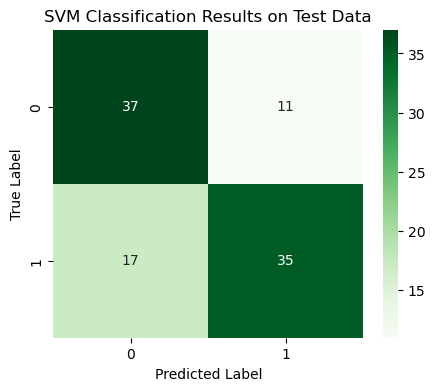

In [51]:
#Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Classification Results on Test Data")
plt.show()

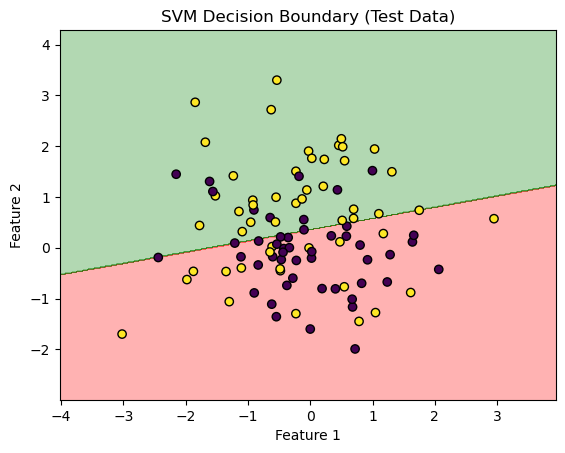

In [127]:
#Decision Boundary Visualization
from matplotlib.colors import ListedColormap

X_vis = X_test.iloc[:, :2].values
y_vis = y_test.values

svm_vis = SVC(kernel='linear')
svm_vis.fit(X_vis, y_vis)

x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('red','green')))
plt.scatter(X_vis[:,0], X_vis[:,1], c=y_vis, edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary (Test Data)")
plt.show()


In [91]:
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)


In [123]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred_rbf)


0.78

In [125]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
grid.best_params_


{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

In [99]:
best_svm = grid.best_estimator_
y_pred_best = best_svm.predict(X_test)

accuracy_score(y_test, y_pred_best)


0.72

In [101]:
kernels = ['linear', 'poly', 'rbf']
results = {}

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[k] = accuracy_score(y_test, pred)

results


{'linear': 0.72, 'poly': 0.72, 'rbf': 0.78}